In [1]:
import os, cv2, tqdm
import numpy as np
import tensorly as tl
import matplotlib.pyplot as plt
from readlif.reader import LifFile, LifImage
import xml.etree.ElementTree as ET
from sklearn.cluster import KMeans
import ramanspy as rp
import skimage
from sklearn.decomposition import PCA
import preprocessing.microscopy_image as mi
import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import constants

import copy
import dill

# Use dill in ProcessPoolExecutor
from concurrent.futures import ProcessPoolExecutor
from dill import Pickler

## Constants Definition

In [2]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Nina"
SAMPLE_ID = "00103993-1"
MODALITY_NAME = "raman"

INPUT_PATH = os.path.join(PATH, SAMPLE_ID, MODALITY_NAME)
OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)
FILENAME = f"{SAMPLE_ID}.lif"

## Leica LIF File loader

In [3]:
def compute_wavenumbers(lambda_begin: float, lambda_end: float, lambda_steps: float, lamnda_stokes: float) -> np.ndarray[np.float32]:
    '''
    Compute the wavenumbers array based on the LIF File metadata
    
    Parameters
    ----------
    lambda_begin : float
        The starting wavelength in nm.
    lambda_end : float
        The ending wavelength in nm.
    lambda_steps : float
        The number of steps in the wavelength range.
    lambda_stokes : float
        The Stokes wavelength in nm.
    '''

    # Compute the laser pump wavelength
    pump_wavelength = np.linspace(lambda_begin, lambda_end, lambda_steps)

    # Compute the Raman wavenumbers
    raman_wavenumbers = ((1 / pump_wavelength) - (1 / lamnda_stokes)) * 1e7

    return raman_wavenumbers

def parse_lif_metadata(lif: LifFile) -> list[dict]:
    
    # Obtain the XML root element from the LifFile object
    root = lif.xml_root

    # Obtain a list of Raman Scans
    top_level_elements = root.findall('./Element')
    if not top_level_elements:
        top_level_elements = root.findall('.')
        if root.tag != 'Element':
                top_level_elements = root.findall('.//Element')

    # Filter out the elements that do not represent scans
    elements_to_process = []
    for top_element in top_level_elements:
        children_tag = top_element.find('Children')
        if children_tag is not None:
            for image_element in children_tag.findall('Element'):
                elements_to_process.append(image_element)
        else:
                if top_element.find('./Data/Image') is not None:
                    elements_to_process.append(top_element)

    # Fallback in case the XML structure is collapsed to a single level
    if not elements_to_process and root.tag == 'LMSDataContainerHeader':
        root_children_tag = root.find('Children')
        if root_children_tag is not None:
            for image_element in root_children_tag.findall('Element'):
                elements_to_process.append(image_element)
        elif root.find('./Element/Data/Image') is not None :
                for image_element in root.findall('Element'):
                    if image_element.find('./Data/Image') is not None:
                        elements_to_process.append(image_element)

    # No elements to process or unexpected structure
    if not elements_to_process:
        raise ValueError("No elements found in the LIF file or unexpected XML structure.")

    result = []

    # Iterate over each element to extract metadata
    for i, element in enumerate(elements_to_process):
        element_name = element.get('Name', f"Unnamed Element {i+1}")
        data_image_tag = element.find('./Data/Image')
        
        metadata = {
            "scan_name": element_name,
            "lambda_steps": None,
            "lambda_begin": None,
            "lambda_end": None,
            "scan_height": None,
            "scan_width": None,
            "laser_type": None,
            "lambda_stokes": None,
            "tile_number": None,
            "tiles_location": None,
        }

        # Get the dimensions
        if data_image_tag is not None:
            image_description = data_image_tag.find('ImageDescription')
            if image_description is not None:                
                dimensions = image_description.find('Dimensions')
                if dimensions is not None and len(list(dimensions)) > 0:
                    for dim_desc in dimensions.findall('DimensionDescription'):
                        id = int(dim_desc.get('DimID', None))
                        size = int(dim_desc.get('NumberOfElements', None))

                        # Interpret the dimension ID for standard Leica LIF files
                        if id == 1:
                            metadata["scan_height"] = size
                        elif id == 2:
                            metadata["scan_width"] = size
                        elif id == 9:
                            metadata["lambda_steps"] = size
                        elif id == 10:
                            metadata["tile_number"] = size

        # Define potential paths for ATLConfocalSettingDefinition
        atl_confocal_paths = [
            './Data/Image/Attachment[@Name="HardwareSetting"]/ATLConfocalSettingDefinition',
            './Data/Image/Attachment[@Name="HardwareSetting"]/LDM_Block_Sequential/LDM_Block_Sequential_Master/ATLConfocalSettingDefinition'
        ]

        found_lambda, found_stokes = False, False

        # Extract Begin and End for Lambda Steps + Lambda Stokes (constant)
        for _, atl_path in enumerate(atl_confocal_paths):
            atl_confocal_setting_def = element.find(atl_path)
            if atl_confocal_setting_def is not None:
                if not found_lambda: 
                    lambda_definition = atl_confocal_setting_def.find('LambdaDefinition')
                    if lambda_definition is not None and len(list(lambda_definition)) > 0:
                        lambda_excitation = lambda_definition.find('LambdaExcitation')
                        
                        if lambda_excitation is not None:
                            metadata["lambda_begin"] = float(lambda_excitation.get('LambdaExcitationBeginDouble', None))
                            metadata["lambda_end"] = float(lambda_excitation.get('LambdaExcitationEndDouble', None))
                            found_lambda = True

                # Extract Lambda Stokes (Pump Wavelength)
                if not found_stokes:
                    laser_array = atl_confocal_setting_def.find('LaserArray')
                    if laser_array is not None:
                        lasers_with_pumpwavelength = []
                        for laser_tag in laser_array.findall('Laser'):
                            pump_wavelength = laser_tag.get('PumpWavelength')
                            if pump_wavelength is not None:
                                laser_name = laser_tag.get('LaserName', 'Unknown Laser')
                                lasers_with_pumpwavelength.append(
                                    f"<Laser Name='{laser_name}' PumpWavelength='{pump_wavelength}' />"
                                )
                        
                        if lasers_with_pumpwavelength:
                            for entry in lasers_with_pumpwavelength:
                                # Parse the entry string into an XML element
                                entry_element = ET.fromstring(entry)
                                metadata["laser_type"] = entry_element.get('Name', None)
                                metadata["lambda_stokes"] = float(entry_element.get('PumpWavelength', None))
                                found_stokes = True
            if found_lambda and found_stokes:
                break
        
        # If the image represents a tile scan, extract info about the tiles
        if metadata["tile_number"] is not None and metadata["tile_number"] > 1:
            tiles = element.findall('./Data/Image/Attachment[@Name="TileScanInfo"]/Tile')
            tiles_metadata = []

            for tile in tiles:
                tiles_metadata.append({
                    "x": float(tile.get('PosX')),
                    "y": float(tile.get('PosY')),
                })
            
            metadata["tiles_location"] = tiles_metadata

        # Append the metadata to the list
        result.append(metadata)

    return result

def load_raman_lif(file: str) -> list[dict]:
    '''
    Load Raman Spectroscopy Imageing data from a Leica LIF file.

    Parameters
    ----------
    file : str
        Path to the LIF file.

    Returns
    ----------
    lif_data : list[dict]
        List of dictionaries containing the image data and metadata.
        Each dictionary contains:
            - "data": List of tiles, each tile is a 3D numpy array (height, width, lambda_steps).
            - "metadata": Dictionary with metadata for the corresponding image.
    '''
    
    lif_file = LifFile(file)
    metadata_array = parse_lif_metadata(lif_file)

    lif_data: list[dict] = []

    # Iterate over the images following the order written in metadata
    for index, metadata in enumerate(metadata_array):

        # Extract only tiled images, ignore automatic stitching
        if metadata["tile_number"] is None or metadata["tile_number"] < 2:
            continue

        # Read the image
        image: LifImage = lif_file.get_image(index)
        tiles: list[np.ndarray[np.float32]] = []

        # Read the tiles
        for tile_idx in range(metadata["tile_number"]):
            tile = np.zeros((metadata["scan_width"], metadata["scan_height"], metadata["lambda_steps"]), dtype=np.float32)

            # For each tile, iterate over the spectral dimensions
            for spectral_idx in range(metadata["lambda_steps"]):
                # Read the image data for each lambda step
                plane = image.get_plane(display_dims=(1, 2), c = 0, requested_dims = {9: spectral_idx, 10: tile_idx})

                # Convert the plane to a numpy array and normalize it between 0 and 1
                plane = np.array(plane, dtype=np.float32)
                plane = cv2.normalize(plane, None, 0, 1, cv2.NORM_MINMAX)
                tile[:, :, spectral_idx] = plane

            # Save the tile
            tiles.append(tile)

        # Save the tile
        lif_data.append({"data": tiles, "metadata": metadata, "wavenumbers": compute_wavenumbers(metadata["lambda_begin"], metadata["lambda_end"], metadata["lambda_steps"], metadata["lambda_stokes"])})

    return lif_data
            

## Tile processing

In [4]:
def check_invalid_values(tile: np.ndarray[np.float32]) -> bool:
    '''
    Check if the tile contains invalid values (NaN or Inf).

    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The tile to check.

    Returns
    ----------
    bool
        True if the tile contains invalid values, False otherwise.
    '''
    
    return np.isnan(tile).any() or np.isinf(tile).any()

In [5]:
def compute_variance_over_spectral_dimensions(
    tile: np.ndarray[np.float32], 
    gamma_correction_factor: float | None = None,
    contrast_enhancement_factor: float | None = None,
    low_variance_threshold: float | None = None,
    high_variance_threshold: float | None = None) -> np.ndarray[np.float32]:
    
    '''
    Compute the variance over the spectral dimensions of a Raman Specroscopy Image tile.

    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The tile to compute the variance over. Expected normalized values with spectral dimension in the last axis.
    gamma_correction_factor : float | None
        The gamma correction factor to apply. Default is None. If None, no correction is applied.
    contrast_enhancement_factor : float | None
        Percentage of pixels to saturate to perform contrast enhancement. Default is None. If None, no enhancement is applied.
    low_variance_threshold : float | None
        Bottom percentile to force to zero variance. Default is None. If None, no threshold is applied.
    high_variance_threshold : float | None
        Top percentile to force to zero variance. Default is None. If None, no threshold is applied.
    
    Returns
    ----------
    np.ndarray[np.float32]
        The variance over the spectral dimensions.
    '''

    # Check the input
    if type(tile) != np.ndarray or len(tile.shape) != 3 or tile.dtype != np.float32:
        raise ValueError("Input tile must be a 3D float32 numpy array with shape (height, width, lambda_steps).")
    
    if low_variance_threshold is not None and (low_variance_threshold < 0 or low_variance_threshold > 1):
        raise ValueError("low_variance_threshold must be between 0 and 1.")
    if high_variance_threshold is not None and (high_variance_threshold < 0 or high_variance_threshold > 1):
        raise ValueError("high_variance_threshold must be between 0 and 1.")
    if contrast_enhancement_factor is not None and (contrast_enhancement_factor < 0 or contrast_enhancement_factor > 1):
        raise ValueError("contrast_enhancement_factor must be between 0 and 1.")
    if gamma_correction_factor is not None and (gamma_correction_factor < 0 or gamma_correction_factor > 1):
        raise ValueError("gamma_correction_factor must be between 0 and 1.")

    # Normalize if necessary
    if (np.min(tile) < 0) or (np.max(tile) > 1):
        tile = cv2.normalize(tile, None, 0, 1, cv2.NORM_MINMAX)

    # Compute the variance over the spectral dimensions
    variance = np.var(tile, axis=-1)

    # Normalize the variance
    variance = cv2.normalize(variance, None, 0, 1, cv2.NORM_MINMAX)

    # Apply gamma correction if requested
    if gamma_correction_factor is not None:
        variance = mi.gamma_correction(variance, gamma = gamma_correction_factor)

    # Apply contrast enhancement if requested
    if contrast_enhancement_factor is not None:
        variance = mi.enhance_contrast(variance, saturated_pixels = contrast_enhancement_factor)

    # Apply low variance threshold if requested
    if low_variance_threshold is not None:
        low_threshold = np.percentile(variance, low_variance_threshold * 100)
        variance[variance < low_threshold] = 0

    # Apply high variance threshold if requested
    if high_variance_threshold is not None:
        high_threshold = np.percentile(variance, high_variance_threshold * 100)
        variance[variance > high_threshold] = 0

    # Apply final normalization
    variance = cv2.normalize(variance, None, 0, 1, cv2.NORM_MINMAX)

    return variance

In [6]:
def compute_variance_over_region(tile: np.ndarray[np.float32], kernel_size: int = 3):
    '''
    Compute the variance over a region of the tile using a local mean and local squared mean.
    
    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The tile to compute the variance over. Expected normalized 2D/3D matrix. For 3D, the last axis is the spectral dimension.
        For 3D, the variance is computed for each spectral dimension independently.
    kernel_size : int
        The size of the kernel to use for the local mean and squared mean. Default is 3.

    Returns
    ----------
    np.ndarray[np.float32]
        The variance over the region of the tile.
    '''

    # Check the input
    if type(tile) != np.ndarray or len(tile.shape) not in [2, 3] or tile.dtype != np.float32:
        raise ValueError("Input tile must be a 2D/3D float32 numpy array with shape (height, width, lambda_steps).")
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd integer.")
    if kernel_size < 1:
        raise ValueError("kernel_size must be greater than 0.")
    
    # Create a kernel for convolution (uniform kernel for average)
    if len(tile.shape) == 2:
        kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)
    else:
        # For 3D, create a kernel for each spectral dimension
        kernel = np.ones((kernel_size, kernel_size, tile.shape[-1]), dtype=np.float32) / (kernel_size * kernel_size)

    # Calculate padding size
    padding = kernel_size // 2
    
    # Pad the image with reflection
    padded_tile = np.pad(tile, padding, mode='reflect')
    
    # Calculate local mean using convolution
    local_mean = cv2.filter2D(padded_tile, -1, kernel)[padding:-padding, padding:-padding]
    
    # Calculate local squared mean
    local_squared_mean = cv2.filter2D(padded_tile**2, -1, kernel)[padding:-padding, padding:-padding]
    
    # Variance = E[X²] - (E[X])²
    local_variance = local_squared_mean - local_mean**2

    # Normalize the variance
    local_variance = cv2.normalize(local_variance, None, 0, 1, cv2.NORM_MINMAX)
        
    return local_variance


In [7]:
def remove_tile_background(tile: np.ndarray[np.float32], morph_tile: np.ndarray[np.float32], plot: bool = False) -> np.ndarray[np.float32]:
    '''
    Using the morphological variance tile, identify and remove the background from the original tile.
    The background is removed by forcing the pixels to a null spectrum.

    Parameters
    ----------
    tile : np.ndarray[np.float32]
        The original tile to remove the background from.
    morph_tile : np.ndarray[np.float32]
        The morphological variance tile to use for background removal.
    plot : bool
        If True, plot the intermediate steps. Default is False.

    Returns
    ----------
    np.ndarray[np.float32]
        The tile with the background removed.
    '''

    # Check the input
    if type(tile) != np.ndarray or len(tile.shape) != 3 or tile.dtype != np.float32:
        raise ValueError("Input tile must be a 3D float32 numpy array with shape (height, width, lambda_steps).")
    if type(morph_tile) != np.ndarray or len(morph_tile.shape) != 2 or morph_tile.dtype != np.float32:
        raise ValueError("Input morph_tile must be a 2D float32 numpy array with shape (height, width).")
    if tile.shape[0] != morph_tile.shape[0] or tile.shape[1] != morph_tile.shape[1]:
        raise ValueError("Input tile and morph_tile must have the same height and width.")
    
    # Normalize if necessary
    if (np.min(tile) < 0) or (np.max(tile) > 1):
        tile = cv2.normalize(tile, None, 0, 1, cv2.NORM_MINMAX)
    if (np.min(morph_tile) < 0) or (np.max(morph_tile) > 1):
        morph_tile = cv2.normalize(morph_tile, None, 0, 1, cv2.NORM_MINMAX)

    if plot:
        plt.figure()
        plt.imshow(morph_tile, cmap='gray')
        plt.title("Morphological variance tile")
        plt.show()

    # From the morphological variance tile, compute again the variance to detect only the borders
    variance_morph_tile = compute_variance_over_region(morph_tile, kernel_size = 5)

    # Normalize everything to 0 - 255
    tile = cv2.normalize(tile, None, 0, 255, cv2.NORM_MINMAX)
    morph_tile = cv2.normalize(morph_tile, None, 0, 255, cv2.NORM_MINMAX)
    tile = np.uint8(tile)
    morph_tile = np.uint8(morph_tile)
    variance_morph_tile = cv2.normalize(variance_morph_tile, None, 0, 255, cv2.NORM_MINMAX)
    variance_morph_tile = np.uint8(variance_morph_tile)

    variance_morph_tile = cv2.threshold(variance_morph_tile, 70, 255, cv2.THRESH_BINARY)[1]

    if plot:
        plt.figure()
        plt.imshow(variance_morph_tile, cmap='gray')
        plt.title("Second order variance")
        plt.show()

    # Final result: regions with high variance
    sharpened_tile = cv2.bitwise_and(morph_tile, morph_tile, mask=variance_morph_tile)
    sharpened_tile = cv2.normalize(sharpened_tile, None, 0, 1, cv2.NORM_MINMAX)

    # Use the sharpened tile to remove the border from the original tile, in each spectral dimension
    sharp_morph_tile = np.where(sharpened_tile > 0, 0, morph_tile)

    if plot:
        plt.figure()
        plt.imshow(sharp_morph_tile, cmap='gray')
        plt.title("Sharpened tile")
        plt.show()

    # Apply an adaptive threshold to get rid of the remaining noise and blur to smooth the image
    sharp_morph_tile = cv2.adaptiveThreshold(sharp_morph_tile, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 20)
    sharp_morph_tile = cv2.GaussianBlur(sharp_morph_tile, (5, 5), 9)

    if plot:
        plt.figure()
        plt.imshow(sharp_morph_tile, cmap='gray')
        plt.title("Final thresholded tile")
        plt.show()

    for _ in range(3):
        sharp_morph_tile = cv2.erode(sharp_morph_tile, np.ones((5, 5), sharp_morph_tile.dtype), iterations = 1)
        sharp_morph_tile = cv2.dilate(sharp_morph_tile, np.ones((5, 5), sharp_morph_tile.dtype), iterations = 2)
        sharp_morph_tile = cv2.erode(sharp_morph_tile, np.ones((5, 5), sharp_morph_tile.dtype), iterations = 1)

    if plot:
        plt.figure()
        plt.imshow(sharp_morph_tile, cmap='gray')
        plt.title("Final thresholded tile")
        plt.show()

    contours, _ = cv2.findContours(sharp_morph_tile, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = sorted(contours, key = cv2.contourArea, reverse = True)[0]
    x, y, w, h = cv2.boundingRect(largest_contour)

    pic = np.ascontiguousarray(np.copy(cv2.normalize(np.mean(tile, axis = -1), None, 0, 255, cv2.NORM_MINMAX)), dtype=sharp_morph_tile.dtype)
    pic = cv2.drawContours(pic, largest_contour, -1, (1.0, 0.0, 0.0), 5)
    pic = cv2.rectangle(pic, (x, y), (x + w, y + h), (0.0, 1.0, 0.0), 5)
    
    if plot:
        plt.figure()
        plt.imshow(pic)
        plt.title("Largest Contour")
        plt.show()

    # From the largest contour, create a mask
    foreground_mask = np.zeros(tile.shape[0:2], dtype = np.uint8)
    cv2.drawContours(foreground_mask, [largest_contour], -1, 255, -1)

    # Apply the mask to the original tile
    masked_tile = np.zeros_like(tile)
    masked_tile[foreground_mask == 255] = tile[foreground_mask == 255]

    if plot:
        plt.figure()
        plt.imshow(np.mean(masked_tile, axis = -1), cmap='gray')
        plt.title("Masked Image")
        plt.show()

    # Normalize the masked tile between 0 and 1 with minmax
    masked_tile = masked_tile.astype(np.float32)
    masked_tile = cv2.normalize(masked_tile, None, 0, 1, cv2.NORM_MINMAX)

    return masked_tile


In [8]:
def process_tile_parallel(tile: np.ndarray[np.float32], wavenumbers: np.ndarray[np.float32], tile_index: int, image_index: int) -> tuple[np.ndarray, int, int]:


    pipeline = rp.preprocessing.Pipeline([
        rp.preprocessing.despike.WhitakerHayes(),
        rp.preprocessing.denoise.SavGol(window_length=9, polyorder=3),
        rp.preprocessing.baseline.IASLS(),
    ])

    # Create a coordinate grid to keep track of the valid pixels
    X, Y, Z = tile.shape
    y_indices, x_indices = np.meshgrid(np.arange(X), np.arange(Y))
    coordinates = np.stack((x_indices, y_indices), axis=-1)

    # Reshape the tile and the coordinates to 2D
    reshaped_tile = tile.reshape(-1, tile.shape[-1])
    reshaped_coordinates = coordinates.reshape(-1, 2)

    # Compute the zero-variance spectra mask
    zero_variance_mask = zero_variance_spectra(reshaped_tile)
    reshaped_tile = reshaped_tile[~zero_variance_mask]
    reshaped_coordinates = reshaped_coordinates[~zero_variance_mask]

    # Create a SpectralImage object
    spectral_image = rp.SpectralImage(reshaped_tile, wavenumbers)

    # Apply the pipeline to the reshaped tile
    processed_tile = pipeline.apply(spectral_image)

    # Normalize the processed tile
    processed_tile = rp.preprocessing.normalise.MinMax().apply(processed_tile)


    processed_tile = processed_tile.spectral_data

    # Reshape the processed tile back to its original shape
    restored_tile = np.zeros((X, Y, Z), dtype=np.float32)

    for i in range(processed_tile.shape[0]):
        x = int(reshaped_coordinates[i, 0])
        y = int(reshaped_coordinates[i, 1])
        restored_tile[x, y, :] = processed_tile[i, :]

    return restored_tile, tile_index, image_index

    

In [9]:
def compute_background_mask(tiles: list[np.ndarray[np.float32]], metadata: list[dict]) -> list[np.ndarray[np.bool]]:
    '''
    Compute a background mask based on the KMeans clustering algorithm.
    For this method, cleaned tiles are needed, they have to be preprocessed first.
    A global PCA is computed over all the tiles. The components are then used to perform the 2 cluster KMeans clustering.
    The cluster with the highest presence in the tile at the center of the image is considered the tissue cluster.

    Parameters
    ----------
    tiles : list[np.ndarray[np.float32]]
        List of tiles to compute the background mask from.
    metadata : list[dict]
        List of metadata dictionaries for each tile
    '''

    # First reshape the tiles to 2D
    reshaped_tiles = [tile.reshape(-1, tile.shape[-1]) for tile in tiles]

    TILE_SIZE = reshaped_tiles[0].shape[0]

    # From the metadata, find the tile in the center of the image
    tiles_coordinates = np.array([(p['x'], p['y']) for p in metadata["tiles_location"]])

    centroid_x = np.sum(tiles_coordinates[:, 0]) / len(tiles_coordinates)
    centroid_y = np.sum(tiles_coordinates[:, 1]) / len(tiles_coordinates)
    distances: np.ndarray = ((tiles_coordinates[:, 0] - centroid_x)**2 + (tiles_coordinates[:, 1] - centroid_y)**2)**0.5
    CENTER_TILE_IDX = distances.argmin()
    print(f"Center tile index: {CENTER_TILE_IDX}")

    # Concatenate all tiles into a single array
    concatenated_tiles = np.concatenate(reshaped_tiles, axis=0)

    # Compute a PCA
    pca = PCA(n_components = 3)
    pca_pixels = pca.fit_transform(concatenated_tiles)

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=2, random_state=0)
    clustered_pixels = kmeans.fit_predict(pca_pixels)

    # Slice only the pixels of the center tile
    center_tile = clustered_pixels[CENTER_TILE_IDX * TILE_SIZE:(CENTER_TILE_IDX + 1) * TILE_SIZE]

    # Count the number of pixels in each cluster
    cluster_counts = np.bincount(center_tile)

    # Find the cluster with the most pixels
    tissue_cluster = np.argmax(cluster_counts)

    # Force the pixels that are not tissue to NaN, to exclude them from the median calculation
    concatenated_tiles[clustered_pixels != tissue_cluster] = np.nan

    # Define the background mask
    background_masks: list[np.ndarray[np.bool]] = []

    for tile_idx in range(len(reshaped_tiles)):

        # Get the tile from the concatenated tiles
        tile = concatenated_tiles[tile_idx * TILE_SIZE:(tile_idx + 1) * TILE_SIZE]
        
        # Compute a binary mask where NaN pixels are background
        mask = np.isnan(tile)
        mask = mask.reshape(tiles[tile_idx].shape)

        # Append the mask to the list
        background_masks.append(mask)

    return background_masks

In [10]:
def correct_tile_spectral_offset(tiles: list[np.ndarray[np.float32]], metadata: list[dict]) -> list[np.ndarray[np.float32]]:
    """
    Correct the spectral offsets (tile batch effects) over the tiles by substituting the tile median with the
    global median, computed using only the valid tissue pixels.

    To identify only the valid tissue pixels, a PCA is performed with 2 KMeans clusters.
    The cluster with the highest presence in the tile at the center of the image is considered the tissue cluster.
    
    Parameters:
    ----------
    
    tiles: list[np.ndarray[np.float32]]
        List of 3D numpy arrays representing the tiles.

    metadata: list[dict]
        List of dictionaries containing the metadata for each tile

    Returns
    ----------
    
    list[np.ndarray[np.float32]]
        List of 3D numpy arrays representing the corrected tiles.
    """

    # Compute the background mask
    background_mask = compute_background_mask(tiles, metadata)

    # Stack all the background masks into a single array
    stacked_masks = np.stack(background_mask, axis=0)

    # Stack tiles into array [num_tiles, x, y, z]
    tiles_array = np.stack(tiles, axis=0)

    # Force the background pixels to NaN
    tiles_array[stacked_masks] = np.nan

    # Calculate global median per spectral channel (z-axis) using only the valid pixels
    global_medians = np.nanmedian(tiles_array, axis=(0, 1, 2))

    print(f"Global medians: {global_medians}")

    # Calculate and apply corrections
    corrected = np.empty_like(tiles_array)
    for t in range(tiles_array.shape[0]):  # Iterate through tiles
        # Calculate tile's median per channel [z,]
        tile_medians = np.nanmedian(tiles_array[t], axis=(0, 1))
        
        # Compute offset per channel
        offsets = global_medians - tile_medians
        
        # Apply correction to all pixels in tile
        corrected[t] = tiles_array[t] + offsets[np.newaxis, np.newaxis, :]
    
    # Maintain original value range (0-1)
    corrected = np.clip(corrected, 0, 1)
    return [corrected[t] for t in range(corrected.shape[0])]


## Tile Composition

In [11]:
def stitch_tiles_from_physical_coords(tiles, physical_coords, tile_shape=(512, 512, 64)):
    """
    Stitch microscope tiles using known pixel size for accurate overlap handling
    
    Args:
        tiles: List of 3D numpy arrays [height, width, depth]
        physical_coords: List of {'x': float, 'y': float} dicts (meters)
        tile_shape: Tuple (height, width, depth) of individual tiles
    
    Returns:
        stitched: 3D numpy array of seamlessly blended image
    """
    # Convert to numpy arrays and extract parameters
    coords_array = np.array([[c['x'], c['y']] for c in physical_coords])
    tile_height, tile_width, depth = tile_shape
    pixel_size = 1.135  # µm/px

    # Convert physical coordinates to pixel positions
    min_coords = coords_array.min(axis=0)
    coords_µm = (coords_array - min_coords) * 1e6  # Convert to micrometers
    pixel_coords = coords_µm / pixel_size  # Convert to pixels
    pixel_coords = np.round(pixel_coords).astype(int)

    # Calculate output dimensions
    max_x = (pixel_coords[:, 0] + tile_width).max()  # Physical X → image columns
    max_y = (pixel_coords[:, 1] + tile_height).max() # Physical Y → image rows
    output_shape = (max_y, max_x, depth)

    # Initialize arrays
    stitched = np.zeros(output_shape, dtype=np.float32)
    weight_map = np.zeros(output_shape[:2], dtype=np.float32)

    # Create radial weight mask (center-weighted blending)
    y_grid, x_grid = np.ogrid[:tile_height, :tile_width]
    center_y, center_x = tile_height//2, tile_width//2
    dist = np.sqrt((x_grid-center_x)**2 + (y_grid-center_y)**2)
    weight = np.clip(1 - dist/dist.max(), 0.3, 1.0)[..., np.newaxis]

    # Stitch tiles with physics-aware blending
    for (x_phys, y_phys), tile in zip(pixel_coords, tiles):
        # Convert physical X/Y to image columns/rows
        x_start = x_phys
        y_start = y_phys
        x_end = x_start + tile_width
        y_end = y_start + tile_height

        # Clamp to array bounds
        x_end = min(x_end, stitched.shape[1])
        y_end = min(y_end, stitched.shape[0])
        valid_width = x_end - x_start
        valid_height = y_end - y_start
        
        if valid_width <= 0 or valid_height <= 0:
            continue

        # Extract target region
        target = stitched[y_start:y_end, x_start:x_end, :]
        target_weights = weight_map[y_start:y_end, x_start:x_end]

        # Apply weighted blending
        tile_slice = tile[:valid_height, :valid_width]
        weight_slice = weight[:valid_height, :valid_width]
        
        blended = (target * target_weights[..., np.newaxis] + tile_slice * weight_slice)
        blended /= (target_weights[..., np.newaxis] + weight_slice + 1e-8)
        
        stitched[y_start:y_end, x_start:x_end, :] = blended
        weight_map[y_start:y_end, x_start:x_end] = np.maximum(
            target_weights, 
            weight_slice[..., 0]
        )

    return stitched


## Misc

In [12]:
def zero_variance_spectra(spectra_array: np.ndarray[np.float32]) -> np.ndarray[np.bool]:
    '''
    Compute the variance across the spectra to identify zero-variance datapoints.
    These datapoints would produce numerical errors in downstream processing so they should be
    removed.

    Parameters
    ----------
    spectra_array : np.ndarray[np.float32]
        The spectra array to compute the variance across. With shape (N, spectra_length)

    Returns
    ----------
    np.ndarray[np.bool]
        A boolean array of the same shape as the input array, where True indicates a zero-variance
        spectrum.
    '''

    forward_differences = np.diff(spectra_array, axis = -1)
    mad = np.median([np.abs(forward_differences - np.median(forward_differences, axis = -1, keepdims=True))], axis = -1)
    
    return np.array(mad == 0, dtype=np.bool).squeeze()


## Plotting

In [13]:
def plot_mean_spectra(tiles: list[np.ndarray[np.float32]], wavenumbers: np.ndarray[np.float32], global_mean: bool = False, title: str | None = None) -> None:
    '''
    Plot the mean spectra. If global_mean is True, plot the mean spectra across all tiles.
    Tiles are expected to be a list of 3D numpy arrays with shape (height, width, spectral_dimension).

    Parameters
    ----------
    tiles : list[np.ndarray[np.float32]]
        The list of tiles to compute the mean spectra over.
    wavenumbers : np.ndarray[np.float32]
        The wavenumbers array to use for the x-axis.
    global_mean : bool
        If True, compute the mean spectra across all tiles. If False, compute the mean spectra for each tile.

    Returns
    ----------
    None
    '''

    mean_spectra: list[np.ndarray[np.float32]] = []
    global_mean_spectra: np.ndarray[np.float32] = np.zeros((tiles[0].shape[-1]), dtype=np.float32)

    for tile in tiles:
        reshaped_tile = tile.reshape(-1, tile.shape[-1])

        # Exclude the zero-variance spectra from the mean calculation
        zero_variance_mask = zero_variance_spectra(reshaped_tile)
        reshaped_tile = reshaped_tile[~zero_variance_mask]


        mean_spectrum = np.mean(reshaped_tile, axis=0)
        mean_spectra.append(mean_spectrum)
        global_mean_spectra += mean_spectrum

    global_mean_spectra /= len(tiles)
    
    # Plot each tile's mean spectrum with a different color
    plt.figure(figsize=(10, 6))
    for i, mean_spectrum in enumerate(mean_spectra):
        plt.plot(wavenumbers, mean_spectrum, label=f'Tile {i+1}')
    
    if global_mean:
        plt.plot(wavenumbers, global_mean_spectra, label='Global Mean', color='black', linewidth=3)

    # Set the x-axis limits
    plt.xlim(np.min(wavenumbers), np.max(wavenumbers))
    
    # Write the x_axis labels using the wavenumbers rounded to integers
    x_labels = [f"{int(wavenumber)}" for wavenumber in wavenumbers]

    # Keep only 5 labels with equal spacing
    num_labels = 5
    step = len(x_labels) // num_labels
    x_labels = [x_labels[i] for i in range(0, len(x_labels), step)]
    wavenumbers = [wavenumbers[i] for i in range(0, len(wavenumbers), step)]

    plt.xticks(ticks=wavenumbers, labels=x_labels, rotation=45)


    plt.xlabel('Wavenumbers (cm-1)')
    plt.ylabel('Intensity')
    plt.title(f'Mean Spectra per Tile {title}')
    plt.legend()
    plt.grid()
    plt.show()


## Data Processing Pipeline

In [14]:
# Load LIF file to obtain the tiles for each image and the relevant metadata
lif_data = load_raman_lif(os.path.join(INPUT_PATH, FILENAME))

# Based on the number of tiles over multiple spectral runs, compute the total number of tiles
total_tiles = 0
for image in lif_data:
    total_tiles += len(image["data"])
print(f"Total number of tiles: {total_tiles}")

Total number of tiles: 33


Text(0.5, 1.0, 'Original Tile')

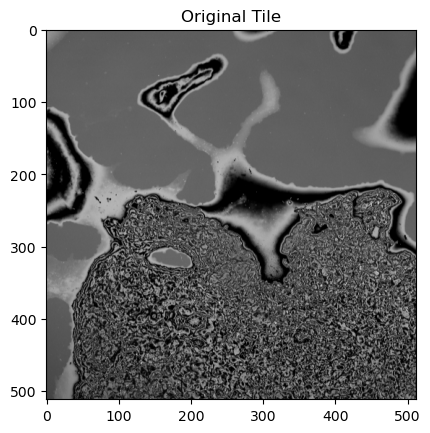

In [15]:
# Inspect one variance tile for debugging
plt.figure()
plt.imshow(np.mean(lif_data[0]["data"][0], axis = -1), cmap='gray')
plt.title("Original Tile")

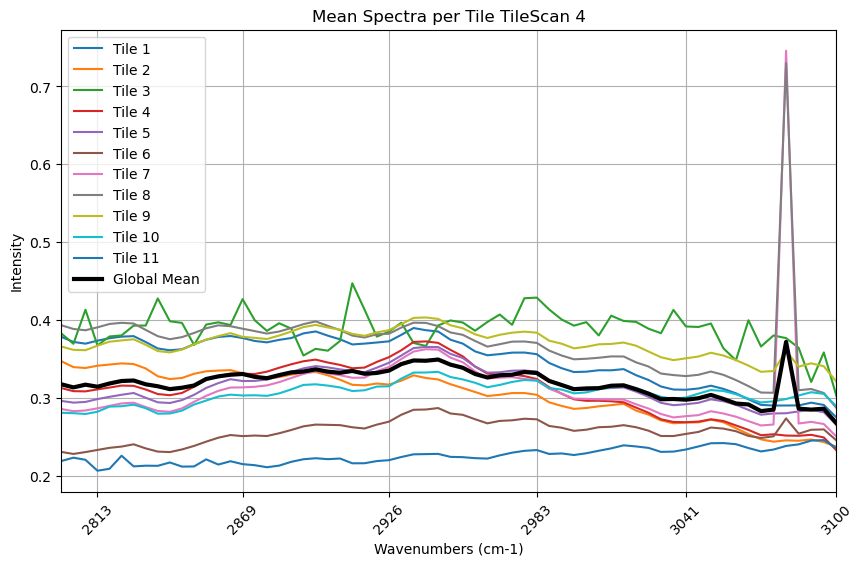

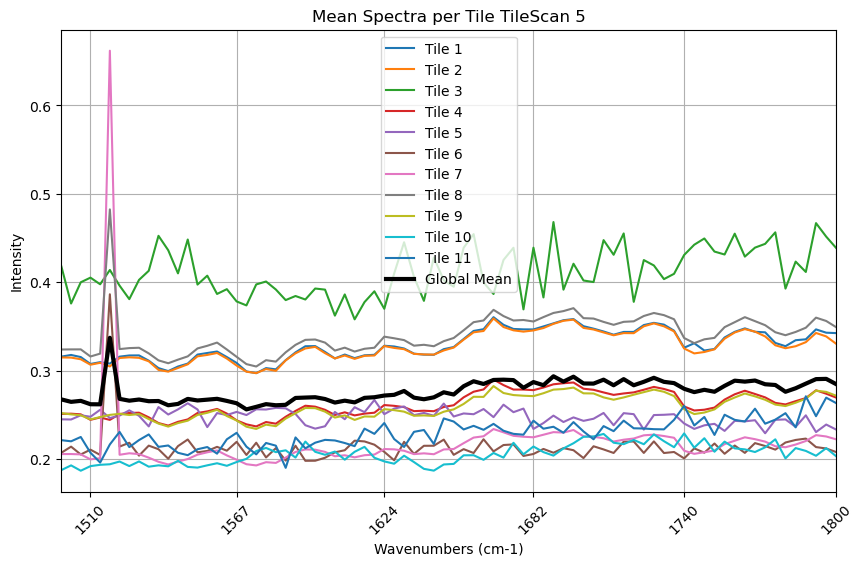

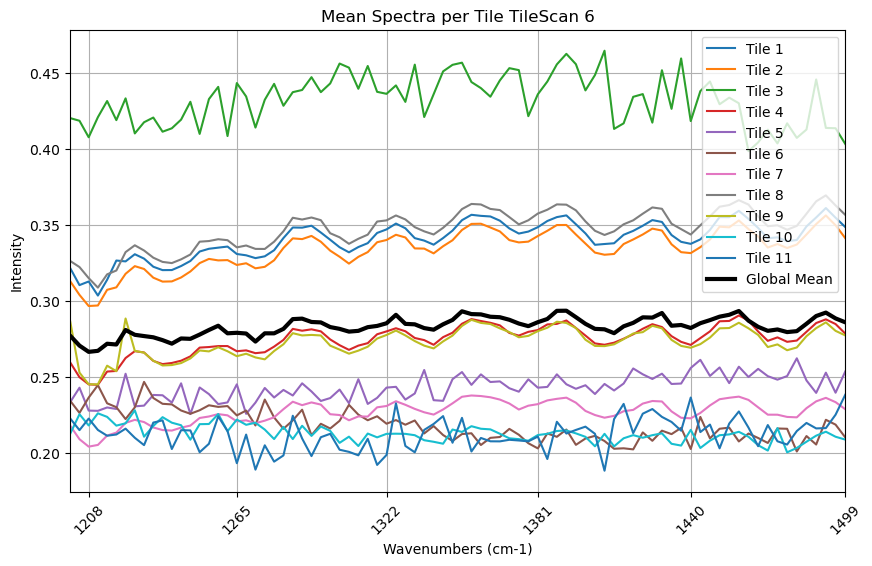

In [16]:
# Print the mean spectra for each tile
for image in lif_data:
    plot_mean_spectra(image["data"], image["wavenumbers"], global_mean=True, title=image["metadata"]["scan_name"])

In [17]:
tile_list = []

# Create a list of tiles to process
for image_idx, image in enumerate(lif_data):
    for tile_idx, tile in enumerate(image["data"]):
        tile_dict = {
            "data": tile,
            "wavenumbers": image["wavenumbers"],
            "tile_index": tile_idx,
            "image_index": image_idx
        }

        tile_list.append(tile_dict)

print(f"Total number of tiles to process: {len(tile_list)}")

with ProcessPoolExecutor() as executor:
    processed_tiles = list(executor.map(
        process_tile_parallel, 
        [x["data"] for x in tile_list], 
        [x["wavenumbers"] for x in tile_list], 
        [x["tile_index"] for x in tile_list],
        [x["image_index"] for x in tile_list],
        )
    )

print(f"Processed {len(processed_tiles)} tiles.")

Total number of tiles to process: 33


/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/mnt/data/lorenzo/miniconda3/envs/pipeline/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/data/lorenzo/miniconda3/envs/pipelin

Processed 33 tiles.


In [18]:
for processed_tile, tile_index, image_index in processed_tiles:

    if "processed" not in lif_data[image_index]:
        lif_data[image_index]["processed"] = []

        # Create empty arrays for the processed tiles
        for _ in range(len(lif_data[image_index]["data"])):
            lif_data[image_index]["processed"].append(np.zeros_like(lif_data[image_index]["data"][0]))

    # Append the processed tile to the corresponding image
    lif_data[image_index]["processed"][tile_index] = processed_tile

for image_idx in range(len(lif_data)):

    background_mask = compute_background_mask(lif_data[image_idx]["processed"], lif_data[image_idx]["metadata"])
    lif_data[image_idx]["raw_masked"] = []

    for tile_idx in range(len(lif_data[image_idx]["processed"])):
        lif_data[image_idx]["raw_masked"].append(np.where(background_mask[tile_idx], 0.0, lif_data[image_idx]["data"][tile_idx]))

Center tile index: 6
Center tile index: 6
Center tile index: 6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.1947386..2.3379579].


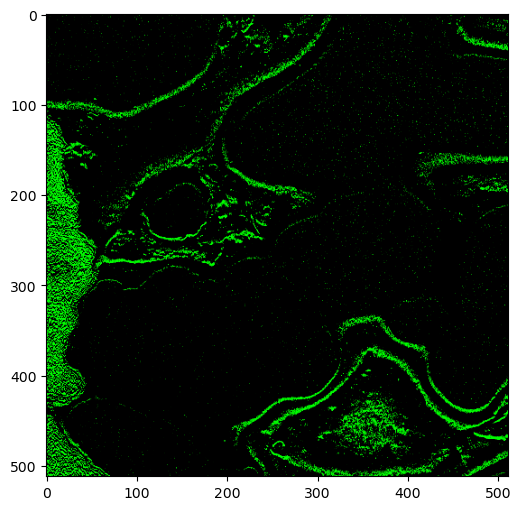

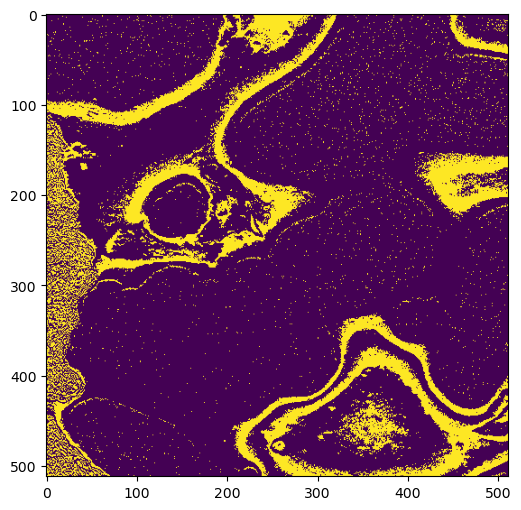

In [38]:
tile: np.ndarray = lif_data[0]["processed"][2]


# Compute PCA
pca = PCA(n_components=3)
pca.fit(np.concatenate([tile.reshape(-1, tile.shape[-1]) for tile in lif_data[0]["processed"]], axis=0))
# Transform the data
pca_transformed = pca.transform(tile.reshape(-1, tile.shape[-1]))
pca_global = pca.transform(np.concatenate([tile.reshape(-1, tile.shape[-1]) for tile in lif_data[0]["processed"]], axis=0))

# Reshape the transformed data back to the original shape
pca_transformed = pca_transformed.reshape(tile.shape[0], tile.shape[1], -1)

# Plot the PCA components
plt.figure(figsize=(10, 6))
plt.imshow(np.stack([np.zeros_like(pca_transformed[:, :, 0]), pca_transformed[:, :, 1], np.zeros_like(pca_transformed[:, :, 0])], axis=-1))

# Perform KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(pca_global)
# Get the cluster labels
cluster_labels = kmeans.predict(pca_transformed.reshape(-1, pca_transformed.shape[-1]))
# Reshape the labels back to the original shape
cluster_labels = cluster_labels.reshape(tile.shape[0], tile.shape[1])

plt.figure(figsize=(10, 6))
plt.imshow(cluster_labels)

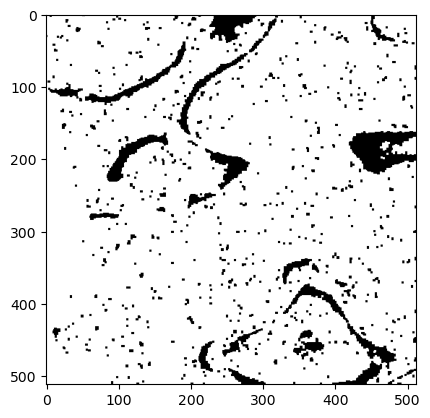

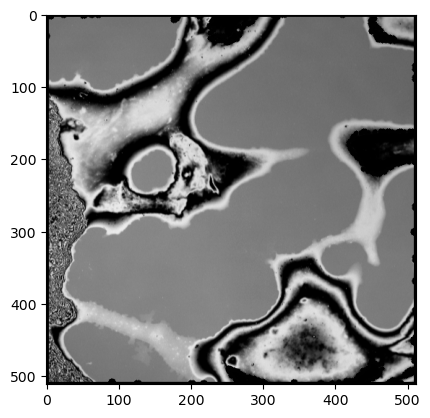

In [20]:

tile: np.ndarray = lif_data[0]["data"][2]
plot = True

f = tile.reshape(-1, tile.shape[-1])
f = f.swapaxes(1, 0)

t = np.std(f - np.mean(f, axis = 0), axis = 1)   
g = np.argmax(t)

data_index = cv2.normalize(tile[:, :, g], None, 0, 255, cv2.NORM_MINMAX)
data_index = np.uint8(data_index)

laplacian = cv2.Laplacian(data_index, cv2.CV_8UC1)
_, thresh = cv2.threshold(laplacian, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)


thresh = cv2.dilate(thresh, np.ones((5, 5), thresh.dtype), iterations = 1)
thresh = cv2.erode(thresh, np.ones((3, 3), thresh.dtype), iterations = 2)
thresh = cv2.dilate(thresh, np.ones((5, 5), thresh.dtype), iterations = 1)
thresh = cv2.erode(thresh, np.ones((3, 3), thresh.dtype), iterations = 1)

contours, _ = cv2.findContours(thresh, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = sorted(contours, key = cv2.contourArea, reverse = True)[0]
x, y, w, h = cv2.boundingRect(largest_contour)

pic = np.ascontiguousarray(np.copy(cv2.normalize(np.mean(tile, axis = -1), None, 0, 255, cv2.NORM_MINMAX)), dtype=thresh.dtype)
pic = cv2.drawContours(pic, largest_contour, -1, (1.0, 0.0, 0.0), 5)
pic = cv2.rectangle(pic, (x, y), (x + w, y + h), (0.0, 1.0, 0.0), 5)

plt.figure()
plt.imshow(thresh, cmap='gray')

plt.figure()
plt.imshow(pic, cmap='gray')


In [21]:
stitched_image = stitch_tiles_from_physical_coords(
    lif_data[0]["processed_corrected"],
    lif_data[0]["metadata"]["tiles_location"],
    tile_shape=lif_data[0]["processed_corrected"][0].shape
)

KeyError: 'processed_corrected'

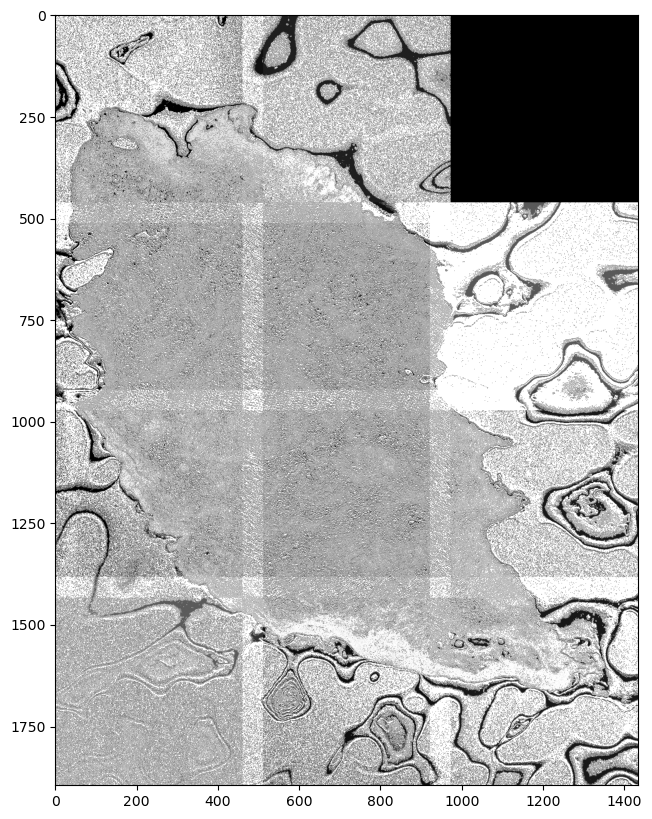

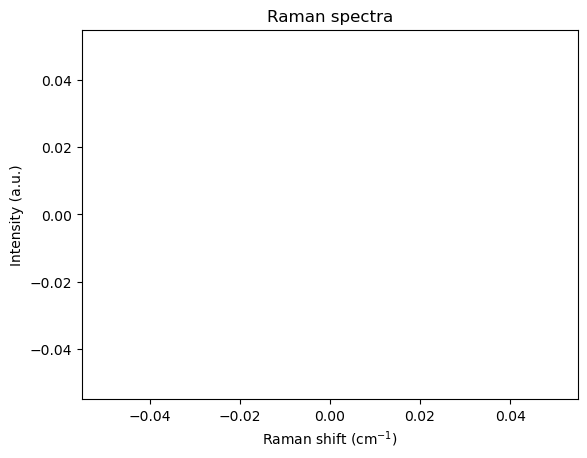

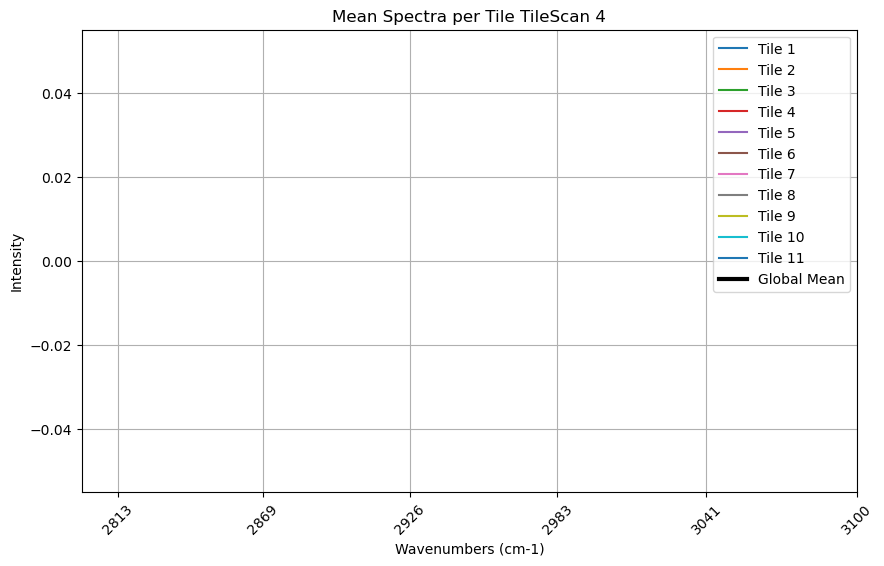

In [ ]:
stitched_image.shape
plt.figure(figsize=(10, 10))
plt.imshow(stitched_image[:, :, 32], cmap='gray')

plt.figure()
rp.plot.mean_spectra(
    stitched_image, 
    lif_data[0]["wavenumbers"], 

)

plot_mean_spectra(lif_data[0]["processed_corrected"], lif_data[0]["wavenumbers"], global_mean=True, title=lif_data[0]["metadata"]["scan_name"])